In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fs = 8000
fc = 1000
N = 21

In [3]:
# wc = 2 * np.pi * fc / fs
n = np.arange(N)
h = (2 * fc / fs) * np.sinc(2 * fc * (n - (N - 1) / 2) / fs)
h *= np.hamming(N)

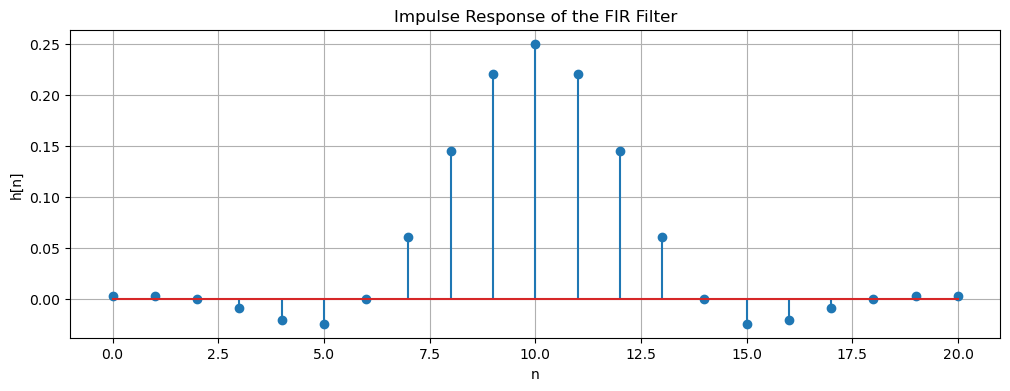

In [4]:
plt.figure(figsize=(12, 4))
plt.stem(n,h)
plt.title('Impulse Response of the FIR Filter')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

In [10]:
#function for n point fft
def n_point_fft(signal, N):
    y = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(len(signal)):
            y[k] += signal[n] * np.exp(-2j * np.pi * k * n / N)
    return y

In [22]:
# Frequency response
# H = np.fft.fft(h, 1024)
H = n_point_fft(h, 1024)
H = np.abs(H)
phase = np.angle(n_point_fft(h, 1024))

# Frequency axis
f = np.linspace(0, fs, 1024)


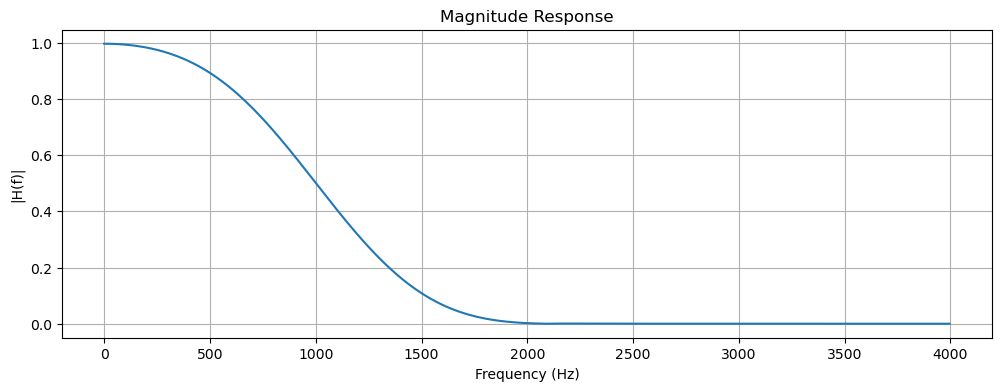

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(f[:512], H[:512])

plt.title("Magnitude Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|H(f)|")
plt.grid()
plt.show()

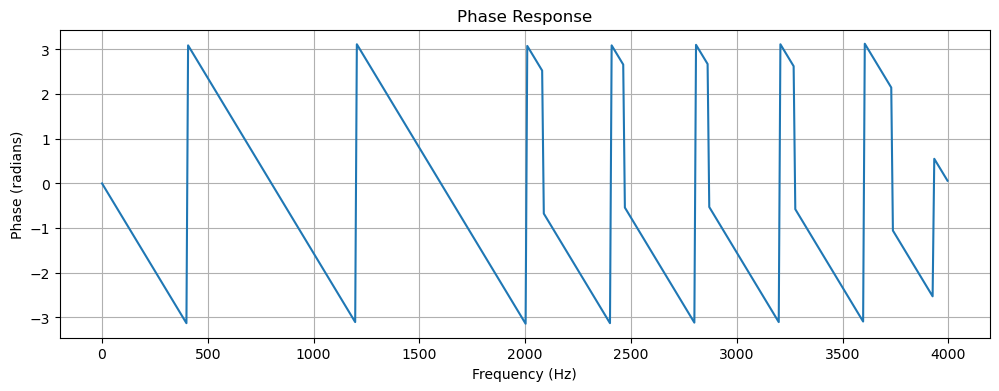

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(f[:512], phase[:512])
plt.title("Phase Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.grid()
plt.show()

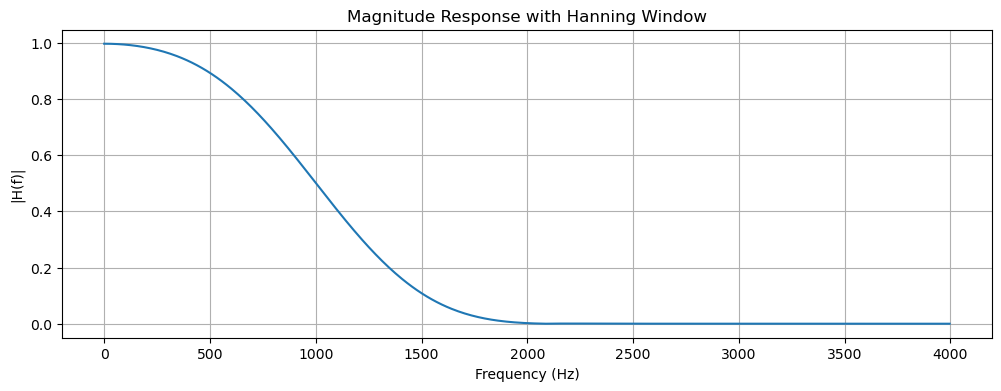

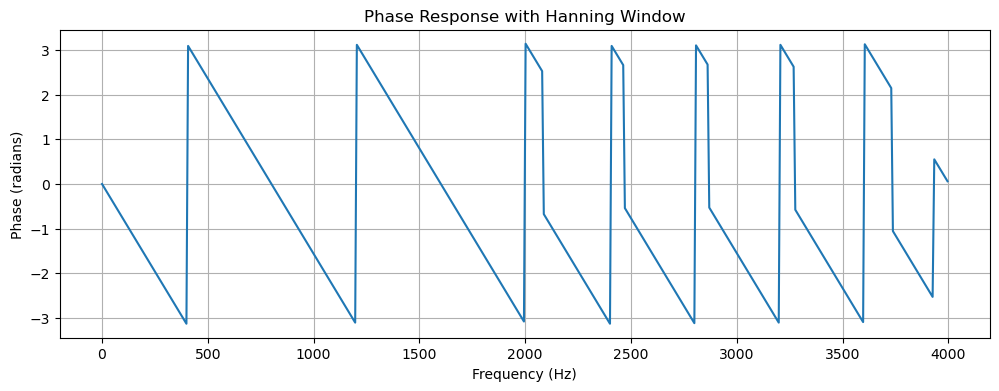

In [8]:
h *= np.hanning(N)
H_hanning = np.fft.fft(h, 1024)
H_hanning = np.abs(H_hanning)
H_hanning_phase = np.angle(np.fft.fft(h, 1024))

plt.figure(figsize=(12, 4))
plt.plot(f[:512], H_hanning[:512])
plt.title("Magnitude Response with Hanning Window")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|H(f)|")
plt.grid()
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(f[:512], H_hanning_phase[:512])
plt.title("Phase Response with Hanning Window")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.grid()
plt.show()
